# SQLite 可视化分析模板

这个模板用于：
- 连接 `db/orders.db`
- 快速浏览表/字段
- 执行 SQL 查询
- 绘制常见分析图（时间序列、分布、分组柱状图、散点图、相关性热力图）

> 你可以直接从上到下运行。

In [1]:
import sqlite3  # 导入 SQLite 驱动
import pandas as pd  # 导入数据处理库 pandas
import matplotlib.pyplot as plt  # 导入绘图库 matplotlib
import seaborn as sns  # 导入统计绘图库 seaborn

plt.style.use('default')  # 使用 matplotlib 默认样式
sns.set_theme(style='whitegrid')  # 设置 seaborn 主题为白底网格

# macOS 中文字体兼容（按顺序尝试）
plt.rcParams['font.sans-serif'] = [  # 设置中文字体候选列表
    'PingFang SC',  # macOS 常见中文字体
    'Hiragino Sans GB',  # macOS 常见中文字体
    'Heiti SC',  # 黑体字体候选
    'STHeiti',  # 华文字体候选
    'Arial Unicode MS',  # Unicode 字体候选
    'Noto Sans CJK SC',  # Noto 中文字体候选
    'SimHei',  # 常见黑体字体候选
]
plt.rcParams['axes.unicode_minus'] = False  # 解决坐标轴负号显示问题

# 稳健数值清洗：把常见字符串数字（逗号/%/U/空值占位）转成可计算数值
def clean_numeric_series(s: pd.Series) -> pd.Series:  # 定义 Series 级别的数值清洗函数
    return pd.to_numeric(  # 将清洗后的字符串统一转为数值
        s.astype(str)  # 先转成字符串，避免类型不一致
        .str.strip()  # 去掉首尾空白
        .str.replace(',', '', regex=False)  # 去掉千分位逗号
        .str.replace('%', '', regex=False)  # 去掉百分号
        .str.replace('U', '', regex=False)  # 去掉金额单位 U
        .replace({'': None, '-': None, '--': None, 'None': None, 'nan': None}),  # 常见空值占位统一为空
        errors='coerce',  # 无法转换的值强制置为 NaN
    )


def convert_numeric_df(df: pd.DataFrame) -> pd.DataFrame:  # 定义 DataFrame 逐列清洗函数
    out = pd.DataFrame(index=df.index)  # 创建同索引的新表用于存放清洗结果
    for c in df.columns:  # 遍历原表所有列
        out[c] = clean_numeric_series(df[c])  # 对每一列应用数值清洗
    return out  # 返回清洗后的新表

DB_PATH = '/Users/yy/.openclaw/workspace/db/orders.db'  # 定义数据库文件路径
conn = None  # 初始化全局连接对象

def ensure_conn():  # 定义连接可用性检查函数
    global conn  # 使用外部全局连接变量
    try:  # 尝试验证现有连接
        if conn is None:  # 如果连接对象为空
            raise RuntimeError('conn is None')  # 主动抛异常进入重连流程
        conn.execute('SELECT 1')  # 用轻量 SQL 测试连接是否有效
    except Exception:  # 若连接不存在或失效
        conn = sqlite3.connect(DB_PATH)  # 重新建立数据库连接
    return conn  # 返回可用连接

conn = ensure_conn()  # 获取并保存可用连接
print('Connected:', DB_PATH)  # 打印连接成功信息

Connected: /Users/yy/.openclaw/workspace/db/orders.db


In [2]:
# 1) 查看数据库里有哪些表
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)  # 查询数据库中所有表名并按名称排序
tables  # 在 Jupyter 中直接展示结果

,name
0,__csv_sync_state
1,__xlsx_sync_state
2,k1_订单数据_2026_03_27
3,k1_订单数据_2026_03_28
4,k1_订单数据_2026_03_29
5,k1_订单数据_2026_03_31
6,k1_订单数据_2026_04_01
7,k2_订单数据_2026_03_27
8,k2_订单数据_2026_03_28
9,k2_订单数据_2026_03_29


In [3]:
# 2) 选择要分析的表（手动优先）
order_tables = [t for t in tables['name'].tolist() if '订单数据' in t]  # 从全部表名中过滤“订单数据”相关表
print('可选订单表:', order_tables)  # 打印可选订单表列表

# 手动指定：不需要手动时设为空字符串 ''
MANUAL_TABLE = 'k1_订单数据_2026_03_28'  # 手动指定目标表名（优先级最高）
TABLE = MANUAL_TABLE if MANUAL_TABLE else (order_tables[0] if order_tables else None)  # 若未手动指定，则自动选第一张订单表
print('TABLE =', TABLE)  # 打印最终使用的表

# 查看字段
if TABLE:  # 若成功确定表名
    schema = pd.read_sql_query(f"PRAGMA table_info('{TABLE}')", conn)  # 查询该表字段结构
    display(schema)  # 展示字段信息
else:  # 若没有可用表
    print('没有找到可用表')  # 输出提示

可选订单表: ['k1_订单数据_2026_03_27', 'k1_订单数据_2026_03_28', 'k1_订单数据_2026_03_29', 'k1_订单数据_2026_03_31', 'k1_订单数据_2026_04_01', 'k2_订单数据_2026_03_27', 'k2_订单数据_2026_03_28', 'k2_订单数据_2026_03_29', 'k2_订单数据_2026_03_31', 'k2_订单数据_2026_04_01']
TABLE = k1_订单数据_2026_03_28


,cid,name,type,notnull,dflt_value,pk
0,0,时间,TEXT,0,None,0
1,1,区块号,TEXT,0,None,0
2,2,单笔盈亏,TEXT,0,None,0
3,3,捆绑费,TEXT,0,None,0
4,4,gas费u,TEXT,0,None,0
5,5,带手续费理论利润,TEXT,0,None,0
6,6,BNB单笔自增长盈亏,TEXT,0,None,0
7,7,稳定币变化量u,TEXT,0,None,0
8,8,交易占比,TEXT,0,None,0
9,9,持仓占比,TEXT,0,None,0


In [4]:
# 3) 读取分析数据（自动识别日期列；默认全量，可配置 LIMIT）
conn = ensure_conn()  # 确保数据库连接可用
if TABLE:  # 若已选定目标表
    schema = pd.read_sql_query(f"PRAGMA table_info('{TABLE}')", conn)  # 读取表结构
    cols = schema['name'].tolist()  # 提取字段名列表
    date_col = next((c for c in ['日期', 'date', 'datetime', 'timestamp', 'time'] if c in cols), None)  # 自动识别时间字段

    START_DATE = '2026-03-01'  # 时间过滤起点（可按需修改）
    SAMPLE_LIMIT = None  # None=全量；例如 20000 表示抽样上限

    if date_col:  # 若存在可用时间列
        sql = f"SELECT * FROM '{TABLE}' WHERE DATE({date_col}) >= DATE('{START_DATE}') ORDER BY {date_col}"  # 基础 SQL（带日期过滤）
    else:  # 若不存在时间列
        sql = f"SELECT * FROM '{TABLE}'"  # 基础 SQL（无日期列则不加过滤）

    if SAMPLE_LIMIT is not None:
        sql += f" LIMIT {int(SAMPLE_LIMIT)}"  # 按需追加 LIMIT

    df = pd.read_sql_query(sql, ensure_conn())  # 执行 SQL 并读取数据
    print('TABLE =', TABLE, '| date_col =', date_col, '| START_DATE =', START_DATE, '| SAMPLE_LIMIT =', SAMPLE_LIMIT, '| shape =', df.shape)
    display(df.head())  # 展示前几行样本
else:  # 若未选到表
    df = pd.DataFrame()  # 回退为空 DataFrame

TABLE = k1_订单数据_2026_03_28 | date_col = None | START_DATE = 2026-03-01 | SAMPLE_LIMIT = None | shape = (41354, 26)


,时间,区块号,单笔盈亏,捆绑费,gas费u,带手续费理论利润,BNB单笔自增长盈亏,稳定币变化量u,交易占比,持仓占比,...,BNB剩余持仓,带手续费捆绑比例,价差,订单交易对手续费,gasprice,wbnb_bundle,WBNB价格,今日交易对盈亏,单笔稳定币自增长盈亏,今日稳定币盈亏
0,2026-03-28 00:00:00,89062928,-0.7492756200892917,0.8238997002505651,0.0054067454804999,0.692851,-1.074147263526403,408.52848113186474,-0.0002845912608061,0.0,...,35.80355953354755,3.562848,0.00057,9999.0,0.05,0.0013492506984541,610.635,-0.7492756200892917,0.0,0.0
1,2026-03-28 00:00:04,89062937,-0.0892857215714844,0.0464239054450259,0.0052591855327499,0.191809,-0.0,-86.86886868623303,0.0023084784973769,0.0009362775872083,...,35.80319923226443,0.129046,0.0046,9999.0,0.05,7.60256215988e-05,610.635,-0.0892857215714844,-0.0,-0.0
2,2026-03-28 00:00:04,89062935,0.6283951575308439,0.0483480428213428,0.005204391450262,0.199506,-0.0,316.3253385183692,-0.0007305488891453,0.0016657110391256,...,35.80348035688257,0.115805,0.001463,9999.0,0.0500001,7.9176664982e-05,610.635,0.6283951575308439,-1.4096630435458952,-1.4096630435458952
3,2026-03-28 00:00:04,89062935,-0.1506122869614112,6.1e-14,0.0056838324793922,0.039184,-0.0,152.5120842920011,-0.000355836226277,0.0017558042417217,...,35.80348035688257,0.052359,0.000712,9999.0,0.0500001,1e-16,610.635,-0.1506122869614112,0.0,0.0
4,2026-03-28 00:00:04,89062937,0.0051336473987812,0.1252406257467688,0.0054826474109999,0.319219,0.0,624.6897453801053,-0.0006100687831356,0.0037134300182162,...,35.803275257886035,0.17148,0.001221,9999.0,0.05,0.0002050989965311,610.635,0.0051336473987812,-0.0,0.0


In [5]:
# 4) 时间序列图（自动识别常见时间字段）
if not df.empty:  # 仅在数据非空时继续绘图
    time_candidates = ['timestamp', 'time', 'datetime', '日期', '创建时间']  # 候选时间字段
    value_candidates = ['equity_curve', '单笔盈亏', 'alpha', 'slippage', 'close', 'price','今日总盈亏（跨1）','今日总盈亏（跨2）','今日总盈亏（跨3）','今日总盈亏（跨12）']  # 候选数值字段

    time_col = next((c for c in time_candidates if c in df.columns), None)  # 自动匹配时间列
    value_col = next((c for c in value_candidates if c in df.columns), None)  # 自动匹配指标列

    if time_col and value_col:  # 只有时间列和指标列都存在才可绘图
        plot_df = df[[time_col, value_col]].copy()  # 提取绘图所需两列
        plot_df[time_col] = pd.to_datetime(plot_df[time_col], errors='coerce')  # 时间列转 datetime
        plot_df[value_col] = clean_numeric_series(plot_df[value_col])  # 指标列转数值
        plot_df = plot_df.dropna().sort_values(time_col)  # 去空值并按时间排序

        plt.figure(figsize=(12, 4))  # 创建画布
        plt.plot(plot_df[time_col], plot_df[value_col], linewidth=1)  # 绘制时间序列线图
        plt.title(f'{value_col} 时间序列')  # 设置标题
        plt.xlabel(time_col)  # 设置 x 轴标签
        plt.ylabel(value_col)  # 设置 y 轴标签
        plt.tight_layout()  # 自动调整布局
        plt.show()  # 展示图表
    else:  # 若未匹配到必要字段
        print('未找到可用时间列或数值列，请手动指定')  # 输出提示

未找到可用时间列或数值列，请手动指定


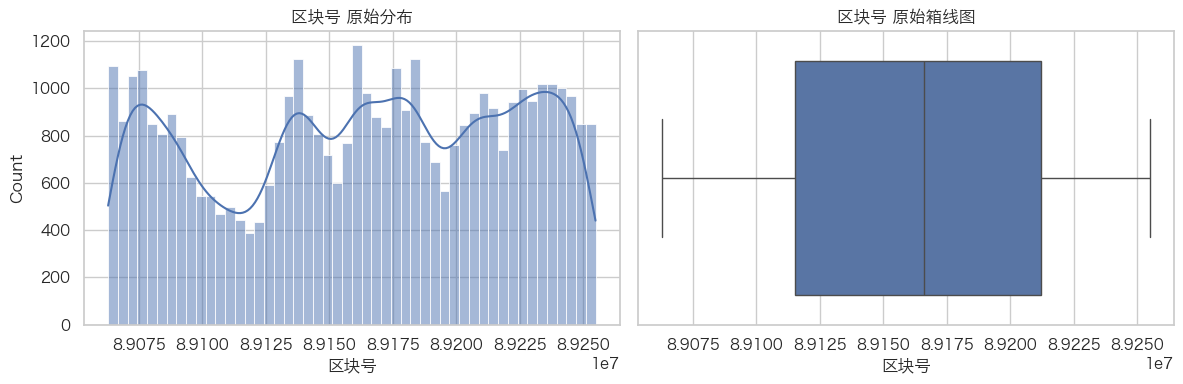

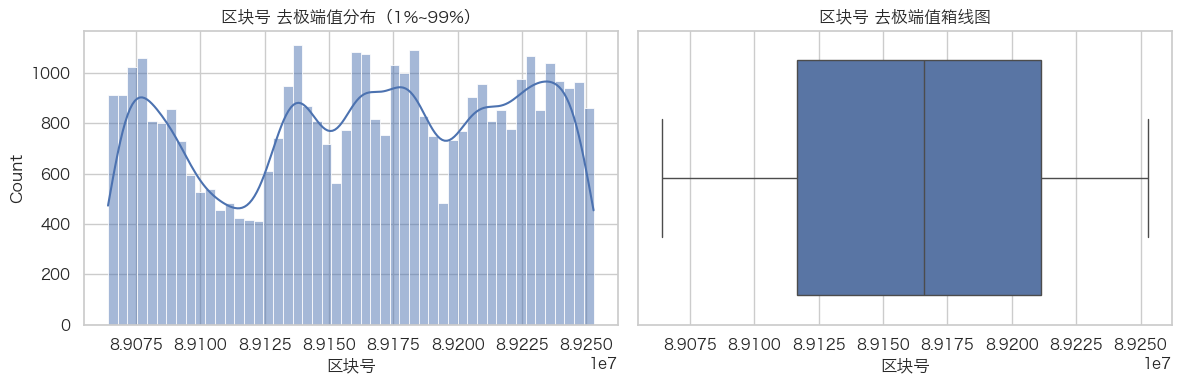

原始样本: 41354，去极端后: 40526，保留比例: 98.00%


In [6]:
# 5) 分布图 + 箱线图 + 去极端值后分布（自动挑一个数值列）
if not df.empty:  # 仅在数据非空时执行
    numeric_df = convert_numeric_df(df)  # 将整表尽量转换为数值
    numeric_cols = [c for c in numeric_df.columns if numeric_df[c].notna().sum() > 0]  # 保留有有效数值的列
    if numeric_cols:  # 若存在可分析数值列
        col = numeric_cols[0]  # 默认选第一列做演示分析
        s = numeric_df[col].dropna()  # 去掉空值，得到有效样本

        # 原始分布 + 箱线图
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 创建 1x2 子图
        sns.histplot(s, bins=50, kde=True, ax=axes[0])  # 绘制原始分布直方图+密度曲线
        axes[0].set_title(f'{col} 原始分布')  # 设置左图标题

        sns.boxplot(x=s, ax=axes[1])  # 绘制原始数据箱线图
        axes[1].set_title(f'{col} 原始箱线图')  # 设置右图标题
        plt.tight_layout()  # 自动调整子图布局
        plt.show()  # 展示原始分布图

        # 去极端值后分布（默认分位数裁剪）
        q_low, q_high = 0.01, 0.99  # 定义上下分位点阈值
        lower = s.quantile(q_low)  # 计算下分位数边界
        upper = s.quantile(q_high)  # 计算上分位数边界
        s_trim = s[(s >= lower) & (s <= upper)]  # 保留分位区间内样本

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 创建去极值后的 1x2 子图
        sns.histplot(s_trim, bins=50, kde=True, ax=axes[0])  # 绘制去极值后分布
        axes[0].set_title(f'{col} 去极端值分布（{int(q_low*100)}%~{int(q_high*100)}%）')  # 设置左图标题

        sns.boxplot(x=s_trim, ax=axes[1])  # 绘制去极值后箱线图
        axes[1].set_title(f'{col} 去极端值箱线图')  # 设置右图标题
        plt.tight_layout()  # 自动调整子图布局
        plt.show()  # 展示去极值后图表

        print(f'原始样本: {len(s)}，去极端后: {len(s_trim)}，保留比例: {len(s_trim)/len(s):.2%}')  # 打印样本保留情况
    else:  # 若没有任何可用数值列
        print('没有可用数值列')  # 输出提示

In [7]:
# 6) 分组统计柱状图（自动尝试常见分类字段）
if not df.empty:  # 仅在数据非空时执行
    group_candidates = ['方向', 'side', 'pair', 'token', 'quote_token']  # 候选分组字段
    value_candidates = ['单笔盈亏', 'alpha', 'slippage', 'equity_return']  # 候选指标字段

    gcol = next((c for c in group_candidates if c in df.columns), None)  # 自动匹配分组列
    vcol = next((c for c in value_candidates if c in df.columns), None)  # 自动匹配数值列

    if gcol and vcol:  # 当分组列与数值列都存在时
        tmp = df[[gcol, vcol]].copy()  # 提取所需列并复制
        tmp[vcol] = clean_numeric_series(tmp[vcol])  # 将指标列清洗为数值
        grp = tmp.dropna().groupby(gcol, as_index=False)[vcol].mean().sort_values(vcol, ascending=False).head(20)  # 按分组求均值并取前20

        plt.figure(figsize=(12, 5))  # 创建柱状图画布
        sns.barplot(data=grp, x=gcol, y=vcol)  # 绘制分组均值柱状图
        plt.xticks(rotation=45, ha='right')  # 旋转 x 轴标签避免重叠
        plt.title(f'{vcol} 按 {gcol} 分组均值（Top20）')  # 设置图标题
        plt.tight_layout()  # 自动调整布局
        plt.show()  # 展示图表
    else:  # 若未识别到必要字段
        print('未找到合适的分组列/数值列，可手动指定')  # 输出提示

未找到合适的分组列/数值列，可手动指定


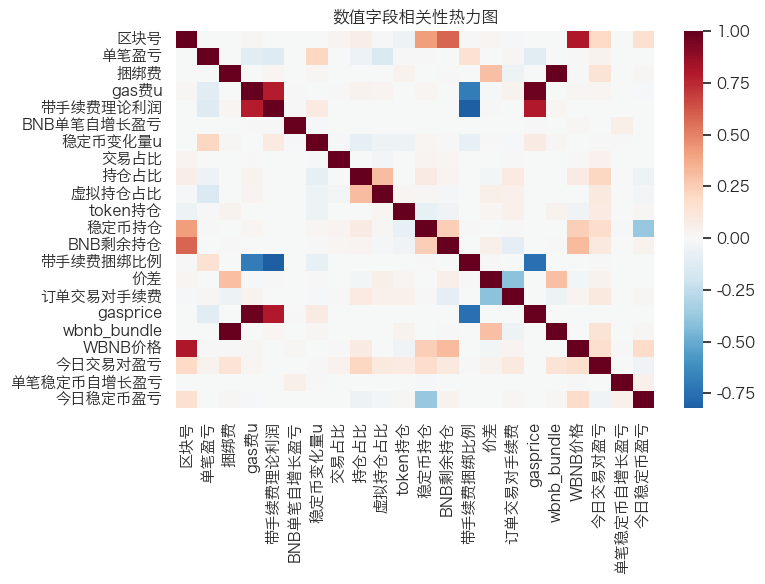

In [8]:
# 7) 数值相关性热力图
if not df.empty:  # 仅在数据非空时执行
    numeric_df = convert_numeric_df(df)  # 将全表尽量转为数值型
    numeric_df = numeric_df.dropna(axis=1, how='all')  # 删除整列全空的字段
    if numeric_df.shape[1] >= 2:  # 至少需要两列数值才能计算相关性
        corr = numeric_df.corr(numeric_only=True)  # 计算数值列相关系数矩阵
        plt.figure(figsize=(8, 6))  # 创建热力图画布
        sns.heatmap(corr, cmap='RdBu_r', center=0)  # 绘制相关性热力图
        plt.title('数值字段相关性热力图')  # 设置图标题
        plt.tight_layout()  # 自动调整布局
        plt.show()  # 展示图表
    else:  # 若可用数值列不足
        print('可用于相关性分析的数值列不足')  # 输出提示

## K1/K2 固定 SQL 模板

下面是常用的分析模板：
- Alpha / slippage 汇总
- 按 quote token 聚合对比
- 按日期趋势对比

> 默认会尝试使用常见表名，请按你实际表名修改。

In [9]:
# 9) 设置 K1/K2 表名（按实际情况修改）
all_tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)["name"].tolist()  # 读取数据库中全部表名
print('all tables:', all_tables)  # 打印全部表名供检查

TABLE_K1 = 'k1_订单数据_2026_03_28'  # 手动指定 K1 表示例
TABLE_K2 = 'k2_订单数据_2026_03_28'  # 手动指定 K2 表示例
print('TABLE_K1 =', TABLE_K1)  # 打印 K1 表名
print('TABLE_K2 =', TABLE_K2)  # 打印 K2 表名

# 如果自动识别不准，手动指定：
# TABLE_K1 = 'k1_订单数据_2026_03_24'  # 手动指定 K1 表示例
# TABLE_K2 = 'k2_订单数据_2026_03_24'  # 手动指定 K2 表示例

all tables: ['__csv_sync_state', '__xlsx_sync_state', 'k1_订单数据_2026_03_27', 'k1_订单数据_2026_03_28', 'k1_订单数据_2026_03_29', 'k1_订单数据_2026_03_31', 'k1_订单数据_2026_04_01', 'k2_订单数据_2026_03_27', 'k2_订单数据_2026_03_28', 'k2_订单数据_2026_03_29', 'k2_订单数据_2026_03_31', 'k2_订单数据_2026_04_01', '跨所每日数据分析_汇总数据']
TABLE_K1 = k1_订单数据_2026_03_28
TABLE_K2 = k2_订单数据_2026_03_28


In [10]:
# 10) Alpha / slippage 汇总对比（K1 vs K2）
def first_existing(cols, candidates):  # 返回候选字段中第一个存在于列名中的字段
    return next((c for c in candidates if c in cols), None)  # 若都不存在则返回 None

def summary_for_table(table_name: str):  # 计算单表汇总指标
    if not table_name:  # 若表名为空
        return None  # 直接返回空结果
    d = pd.read_sql_query(f"SELECT * FROM '{table_name}' LIMIT 50000", conn)  # 读取该表最多 5 万行样本
    cols = d.columns.tolist()  # 获取字段名列表

    alpha_col = first_existing(cols, ['alpha', 'Alpha'])  # 自动识别 alpha 列
    slippage_col = first_existing(cols, ['slippage', 'Slippage'])  # 自动识别 slippage 列
    pnl_col = first_existing(cols, ['单笔盈亏', 'pnl', 'profit'])  # 自动识别盈亏列

    out = {'table': table_name, 'rows': len(d)}  # 初始化输出字典
    if alpha_col:  # 若识别到 alpha 列
        out['alpha_sum'] = pd.to_numeric(d[alpha_col], errors='coerce').sum()  # 计算 alpha 累计值
        out['alpha_mean'] = pd.to_numeric(d[alpha_col], errors='coerce').mean()  # 计算 alpha 均值
    if slippage_col:  # 若识别到 slippage 列
        out['slippage_sum'] = pd.to_numeric(d[slippage_col], errors='coerce').sum()  # 计算 slippage 累计值
        out['slippage_mean'] = pd.to_numeric(d[slippage_col], errors='coerce').mean()  # 计算 slippage 均值
    if pnl_col:  # 若识别到盈亏列
        out['pnl_sum'] = pd.to_numeric(d[pnl_col], errors='coerce').sum()  # 计算盈亏累计值
        out['pnl_mean'] = pd.to_numeric(d[pnl_col], errors='coerce').mean()  # 计算盈亏均值
    return out  # 返回当前表汇总结果

rows = []  # 创建结果列表
for tb in [TABLE_K1, TABLE_K2]:  # 遍历 K1 和 K2 两张表
    r = summary_for_table(tb)  # 计算单表汇总
    if r:  # 若结果非空
        rows.append(r)  # 加入结果列表

summary_df = pd.DataFrame(rows)  # 汇总成 DataFrame
display(summary_df)  # 展示对比结果

,table,rows,pnl_sum,pnl_mean
0,k1_订单数据_2026_03_28,41354,1114.965140,0.026961
1,k2_订单数据_2026_03_28,48315,8075.910654,0.167151


,table,token,metric_sum
0,k1_订单数据_2026_03_28,BSB>USDT,15458.422636
1,k1_订单数据_2026_03_28,RIVER>USDT,15180.711026
2,k1_订单数据_2026_03_28,SIREN>USDT,5582.849607
3,k1_订单数据_2026_03_28,C>USDT,980.250625
4,k1_订单数据_2026_03_28,TRIA>USDT,960.225701
5,k1_订单数据_2026_03_28,LAB>USDT,814.758556
6,k1_订单数据_2026_03_28,PTB>USDC,808.478866
7,k1_订单数据_2026_03_28,SIREN>USDC,579.107446
8,k1_订单数据_2026_03_28,USDT>Q,571.346389
9,k1_订单数据_2026_03_28,ARIA>USDT,544.902085


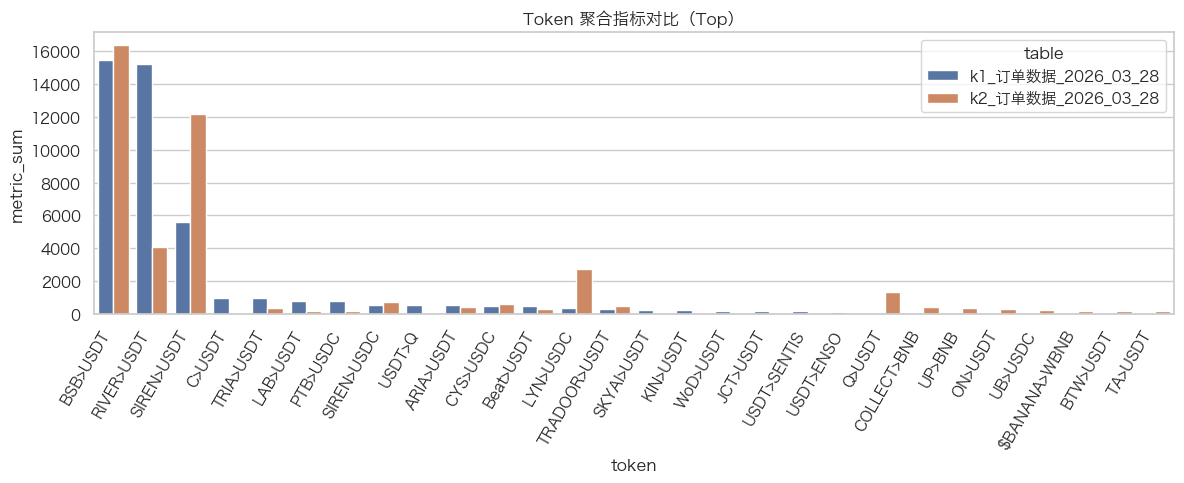

In [11]:
# 11) 按 quote token 聚合（以 slippage / alpha / pnl 为例）
def token_agg(table_name: str, topn: int = 20):  # 定义按 token 聚合函数
    if not table_name:  # 若表名为空
        return pd.DataFrame()  # 返回空表
    d = pd.read_sql_query(f"SELECT * FROM '{table_name}' LIMIT 100000", conn)  # 读取最多 10 万行样本
    cols = d.columns.tolist()  # 获取字段名列表

    token_col = first_existing(cols, ['quote_token', 'quoteToken', '报价token', 'token', '交易对'])  # 自动识别 token 列
    metric_col = first_existing(cols, ['slippage', 'alpha', '单笔盈亏', 'pnl'])  # 自动识别指标列
    if not token_col or not metric_col:  # 若缺少 token 或指标列
        print(f'{table_name}: 缺少 token 或指标列')  # 打印提示
        return pd.DataFrame()  # 返回空表

    d[metric_col] = pd.to_numeric(d[metric_col], errors='coerce')  # 指标列转数值
    g = d.dropna(subset=[metric_col]).groupby(token_col, as_index=False)[metric_col].sum()  # 按 token 汇总指标总和
    g = g.sort_values(metric_col, ascending=False).head(topn)  # 按指标降序并取 TopN
    g['table'] = table_name  # 增加来源表标识
    g = g.rename(columns={token_col: 'token', metric_col: 'metric_sum'})  # 统一输出字段名
    return g[['table', 'token', 'metric_sum']]  # 返回标准结果列

k1_tok = token_agg(TABLE_K1)  # 计算 K1 token 聚合
k2_tok = token_agg(TABLE_K2)  # 计算 K2 token 聚合
res_tok = pd.concat([k1_tok, k2_tok], ignore_index=True)  # 合并 K1/K2 结果
display(res_tok.head(30))  # 展示前 30 行结果

if not res_tok.empty:  # 若结果非空则绘图
    plt.figure(figsize=(12, 5))  # 创建画布
    sns.barplot(data=res_tok, x='token', y='metric_sum', hue='table')  # 绘制按 token 对比柱状图
    plt.xticks(rotation=60, ha='right')  # 旋转 x 轴标签防重叠
    plt.title('Token 聚合指标对比（Top）')  # 设置图标题
    plt.tight_layout()  # 自动调整布局
    plt.show()  # 展示图表

In [12]:
# 12) 按日期聚合趋势（K1/K2）
def daily_trend(table_name: str):  # 定义单表按日趋势聚合函数
    if not table_name:  # 若表名为空
        return pd.DataFrame()  # 返回空表
    d = pd.read_sql_query(f"SELECT * FROM '{table_name}' LIMIT 100000", conn)  # 读取最多 10 万行样本
    cols = d.columns.tolist()  # 获取字段列表

    date_col = first_existing(cols, ['日期', 'date', 'datetime', 'timestamp'])  # 自动识别日期列
    metric_col = first_existing(cols, ['单笔盈亏', 'pnl', 'alpha', 'slippage'])  # 自动识别指标列
    if not date_col or not metric_col:  # 若缺少必要字段
        print(f'{table_name}: 缺少日期或指标列')  # 输出提示
        return pd.DataFrame()  # 返回空表

    x = d[[date_col, metric_col]].copy()  # 提取日期和指标两列
    x[date_col] = pd.to_datetime(x[date_col], errors='coerce')  # 日期列转 datetime
    x[metric_col] = pd.to_numeric(x[metric_col], errors='coerce')  # 指标列转数值
    x = x.dropna()  # 删除空值行
    x['day'] = x[date_col].dt.date  # 提取自然日用于聚合
    g = x.groupby('day', as_index=False)[metric_col].sum()  # 按天汇总指标总和
    g['table'] = table_name  # 增加表名标识
    g = g.rename(columns={metric_col: 'metric_sum'})  # 统一指标字段名
    return g  # 返回日级聚合结果

trend = pd.concat([daily_trend(TABLE_K1), daily_trend(TABLE_K2)], ignore_index=True)  # 合并 K1/K2 日趋势
display(trend.head())  # 展示趋势结果前几行

if not trend.empty:  # 若结果非空则绘图
    plt.figure(figsize=(12, 4))  # 创建画布
    sns.lineplot(data=trend, x='day', y='metric_sum', hue='table', marker='o')  # 绘制按日折线对比图
    plt.xticks(rotation=45, ha='right')  # 旋转 x 轴标签
    plt.title('按日期聚合指标趋势')  # 设置图标题
    plt.tight_layout()  # 自动调整布局
    plt.show()  # 展示图表

k1_订单数据_2026_03_28: 缺少日期或指标列
k2_订单数据_2026_03_28: 缺少日期或指标列


""


In [13]:
# 8) 连接关闭请放在全部分析完成后的最后一步执行
print('提示：请在 notebook 最后一个步骤再执行关闭连接，避免中途查询报 closed database。')

提示：请在 notebook 最后一个步骤再执行关闭连接，避免中途查询报 closed database。


In [14]:
# 13.1) 口径对齐检查：为什么“总行数”和“区间样本”会不同
if 'df' in globals() and not df.empty:
    print('当前 df 行数 =', len(df), '| 当前 TABLE =', TABLE)

    # 与汇总口径对齐：查看 K1/K2 各表总行数
    table_rows = pd.read_sql_query(
        "SELECT name AS table_name FROM sqlite_master WHERE type='table' AND (name LIKE 'k1_%订单数据%' OR name LIKE 'k2_%订单数据%') ORDER BY name",
        ensure_conn(),
    )
    if not table_rows.empty:
        out = []
        for tb in table_rows['table_name'].tolist():
            n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM '{tb}'", ensure_conn()).iloc[0]['n']
            out.append({'table': tb, 'rows': int(n)})
        display(pd.DataFrame(out))

    # 分类口径检查（以价差为例）：区间总行数 + NaN区间行数 应约等于用于分桶输入行数
    cols = df.columns.tolist()
    pnl_col = next((c for c in ['单笔盈亏', 'pnl', 'profit'] if c in cols), None)
    gap_col = next((c for c in ['价差', '价差率', 'price_gap', 'price_diff', '带手续费理论利润'] if c in cols), None)
    if pnl_col and gap_col:
        tmp = df[[gap_col, pnl_col]].copy().dropna(how='all')
        tmp[pnl_col] = clean_numeric_series(tmp[pnl_col])
        tmp[gap_col] = clean_numeric_series(tmp[gap_col]).abs()
        bins = [0, 0.0005, 0.001, 0.002, 0.005, 0.01, float('inf')]
        labels = ['<0.05%', '0.05%-0.1%', '0.1%-0.2%', '0.2%-0.5%', '0.5%-1%', '>1%']
        tmp['价差区间'] = pd.cut(tmp[gap_col], bins=bins, labels=labels, right=False)
        print('分类输入行数(tmp) =', len(tmp))
        print('区间非空行数 =', tmp['价差区间'].notna().sum(), '| 区间为空行数 =', tmp['价差区间'].isna().sum())
        print('盈亏有效样本数 =', tmp[pnl_col].notna().sum(), '| 盈亏空值数 =', tmp[pnl_col].isna().sum())
else:
    print('请先运行数据读取单元，确保 df 已加载。')

当前 df 行数 = 41354 | 当前 TABLE = k1_订单数据_2026_03_28


,table,rows
0,k1_订单数据_2026_03_27,42939
1,k1_订单数据_2026_03_28,41354
2,k1_订单数据_2026_03_29,29412
3,k1_订单数据_2026_03_31,10151
4,k1_订单数据_2026_04_01,42816
5,k2_订单数据_2026_03_27,63472
6,k2_订单数据_2026_03_28,48315
7,k2_订单数据_2026_03_29,41822
8,k2_订单数据_2026_03_31,11081
9,k2_订单数据_2026_04_01,55223


分类输入行数(tmp) = 41354
区间非空行数 = 41354 | 区间为空行数 = 0
盈亏有效样本数 = 41354 | 盈亏空值数 = 0


In [15]:
# 13) 区间分类分析（价差 / 规模 / 持仓占比）
# 说明：基于订单数据常见字段自动识别并分桶，输出每个区间的样本数与盈亏表现。

if 'df' in globals() and not df.empty:  # 检查 df 是否存在且非空
    work = df.copy()  # 复制一份工作数据，避免污染原始 df
    cols = work.columns.tolist()  # 获取字段名列表

    def first_existing(cols, cands):  # 定义“从候选中选第一个存在列”的工具函数
        return next((c for c in cands if c in cols), None)  # 返回命中的第一个列名或 None

    # 核心列识别
    pnl_col = first_existing(cols, ['单笔盈亏', 'pnl', 'profit'])  # 自动识别盈亏列
    gap_col = first_existing(cols, ['价差', '价差率', 'price_gap', 'price_diff', '带手续费理论利润'])  # 自动识别价差列
    size_col = first_existing(cols, ['稳定币变化量u', '总交易量', 'trade_size', 'size'])  # 自动识别规模列
    pos_col = first_existing(cols, ['持仓占比', '虚拟持仓占比', '交易占比', 'position_ratio'])  # 自动识别持仓占比列

    print('pnl_col =', pnl_col)  # 打印盈亏列识别结果
    print('gap_col =', gap_col)  # 打印价差列识别结果
    print('size_col =', size_col)  # 打印规模列识别结果
    print('pos_col =', pos_col)  # 打印持仓列识别结果

    if not pnl_col:  # 若缺失盈亏列
        print('缺少盈亏列，无法做区间归因')  # 输出无法分析的原因
    else:  # 若盈亏列存在
        work[pnl_col] = clean_numeric_series(work[pnl_col])  # 先把盈亏列清洗为数值

        # 1) 价差区间（默认按绝对值分桶）
        if gap_col:  # 若存在价差列
            g = work[[gap_col, pnl_col]].copy().dropna(how='all')  # 提取价差与盈亏并去掉全空行
            g[gap_col] = clean_numeric_series(g[gap_col]).abs()  # 价差转数值并取绝对值
            # 若有效样本不足，跳过
            if g[gap_col].notna().sum() >= 20:  # 至少 20 个有效样本再做分桶
                # 价差区间按百分比划分：0.05% / 0.1% / 0.2% / 0.5% / 1% / >1%
                # 注意：这里按“比例值”分桶，0.05% = 0.0005
                gap_bins = [0, 0.0005, 0.001, 0.002, 0.005, 0.01, float('inf')]  # 定义价差分桶边界
                gap_labels = ['<0.05%', '0.05%-0.1%', '0.1%-0.2%', '0.2%-0.5%', '0.5%-1%', '>1%']  # 定义价差分桶标签
                g['价差区间'] = pd.cut(g[gap_col], bins=gap_bins, labels=gap_labels, right=False)  # 执行价差分桶
                gap_stats = (  # 构建价差分桶统计表
                    g.groupby('价差区间', dropna=False)  # 按价差区间分组
                    .agg(总行数=(pnl_col, 'size'), 有效盈亏样本=(pnl_col, 'count'), 均值盈亏=(pnl_col, 'mean'), 累计盈亏=(pnl_col, 'sum'))  # 同时统计总行数与有效样本
                    .reset_index()  # 重置索引便于展示
                )
                print('\n[价差区间分类]')  # 打印分节标题
                display(gap_stats)  # 展示价差区间统计结果

        # 2) 规模区间
        if size_col:  # 若存在规模列
            s = work[[size_col, pnl_col]].copy().dropna(how='all')  # 提取规模与盈亏并去掉全空行
            s[size_col] = clean_numeric_series(s[size_col]).abs()  # 规模转数值并取绝对值
            if s[size_col].notna().sum() >= 20:  # 至少 20 个有效样本再做分桶
                size_bins = [0, 50, 100, 500, 1000, 5000, float('inf')]  # 定义规模分桶边界
                size_labels = ['<50', '50-100', '100-500', '500-1k', '1k-5k', '>5k']  # 定义规模分桶标签
                s['规模区间'] = pd.cut(s[size_col], bins=size_bins, labels=size_labels, right=False)  # 执行规模分桶
                size_stats = (  # 构建规模分桶统计表
                    s.groupby('规模区间', dropna=False)  # 按规模区间分组
                    .agg(总行数=(pnl_col, 'size'), 有效盈亏样本=(pnl_col, 'count'), 均值盈亏=(pnl_col, 'mean'), 累计盈亏=(pnl_col, 'sum'))  # 同时统计总行数与有效样本
                    .reset_index()  # 重置索引便于展示
                )
                print('\n[规模区间分类]')  # 打印分节标题
                display(size_stats)  # 展示规模区间统计结果

        # 3) 持仓占比区间
        if pos_col:  # 若存在持仓占比列
            p = work[[pos_col, pnl_col]].copy().dropna(how='all')  # 提取持仓占比与盈亏并去掉全空行
            p[pos_col] = clean_numeric_series(p[pos_col]).abs()  # 持仓占比转数值并取绝对值
            if p[pos_col].notna().sum() >= 20:  # 至少 20 个有效样本再做分桶
                pos_bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0, float('inf')]  # 定义持仓占比分桶边界
                pos_labels = ['0-10%', '10-30%', '30-50%', '50-70%', '70-100%', '100%+']  # 定义持仓占比分桶标签
                p['持仓占比区间'] = pd.cut(p[pos_col], bins=pos_bins, labels=pos_labels, right=False)  # 执行持仓占比分桶
                pos_stats = (  # 构建持仓分桶统计表
                    p.groupby('持仓占比区间', dropna=False)  # 按持仓占比区间分组
                    .agg(总行数=(pnl_col, 'size'), 有效盈亏样本=(pnl_col, 'count'), 均值盈亏=(pnl_col, 'mean'), 累计盈亏=(pnl_col, 'sum'))  # 同时统计总行数与有效样本
                    .reset_index()  # 重置索引便于展示
                )
                print('\n[持仓占比区间分类]')  # 打印分节标题
                display(pos_stats)  # 展示持仓区间统计结果
else:  # 若 df 不存在或为空
    print('请先运行前面的数据读取单元，确保 df 已加载。')  # 输出提示信息

pnl_col = 单笔盈亏
gap_col = 价差
size_col = 稳定币变化量u
pos_col = 持仓占比

[价差区间分类]


,价差区间,总行数,有效盈亏样本,均值盈亏,累计盈亏
0,<0.05%,3458,3458,-0.621216,-2148.165771
1,0.05%-0.1%,13124,13124,-0.110263,-1447.097229
2,0.1%-0.2%,15587,15587,0.127490,1987.190476
3,0.2%-0.5%,6989,6989,0.401972,2809.383673
4,0.5%-1%,1805,1805,0.183303,330.861564
5,>1%,391,391,-1.067027,-417.207573



[规模区间分类]


,规模区间,总行数,有效盈亏样本,均值盈亏,累计盈亏
0,<50,2187,2187,-0.699351,-1529.480827
1,50-100,4831,4831,-0.198182,-957.415201
2,100-500,23360,23360,0.030971,723.479856
3,500-1k,8745,8745,0.258368,2259.425866
4,1k-5k,2209,2209,0.614351,1357.100812
5,>5k,22,22,-33.552062,-738.145366



[持仓占比区间分类]


,持仓占比区间,总行数,有效盈亏样本,均值盈亏,累计盈亏
0,0-10%,41312,41312,0.032111,1326.589187
1,10-30%,40,40,-4.250369,-170.014748
2,30-50%,2,2,-20.804650,-41.609299


## 可视化增强（Order Analysis）

补充固定图版，便于快速汇报与横向对比。

,table,rows,pnl_sum,pnl_mean
0,k1_订单数据_2026_03_28,41354,1114.965140,0.026961
1,k2_订单数据_2026_03_28,48315,8075.910654,0.167151


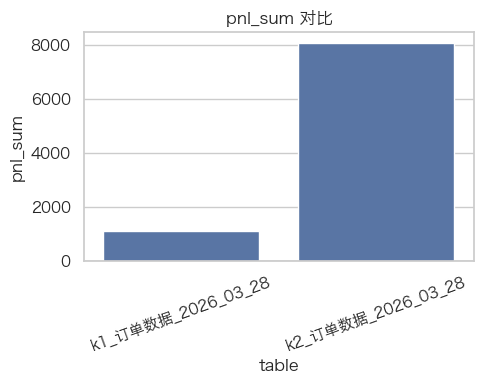

In [16]:
# A) K1/K2 核心指标对比（表格+柱状图）
if 'summary_df' in globals() and not summary_df.empty:
    display(summary_df)

    m = summary_df.copy()
    value_cols = [c for c in ['pnl_sum', 'alpha_sum', 'slippage_sum'] if c in m.columns]
    if value_cols:
        fig, axes = plt.subplots(1, len(value_cols), figsize=(5 * len(value_cols), 4))
        if len(value_cols) == 1:
            axes = [axes]

        for ax, c in zip(axes, value_cols):
            sns.barplot(data=m, x='table', y=c, ax=ax)
            ax.set_title(f'{c} 对比')
            ax.tick_params(axis='x', rotation=20)
            ax.axhline(0, color='black', linewidth=0.8)

        plt.tight_layout()
        plt.show()
else:
    print('请先运行汇总对比单元（summary_df）。')

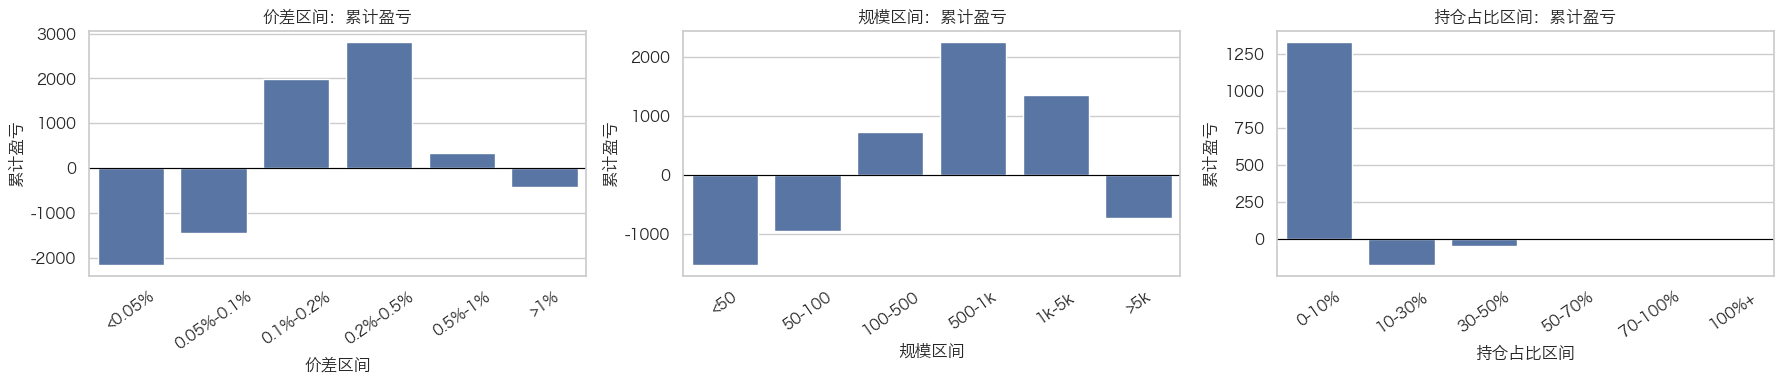

In [17]:
# B) 区间分类总览（价差/规模/持仓占比）
stats_map = {
    '价差区间': globals().get('gap_stats'),
    '规模区间': globals().get('size_stats'),
    '持仓占比区间': globals().get('pos_stats'),
}

available = [(k, v) for k, v in stats_map.items() if isinstance(v, pd.DataFrame) and not v.empty]
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 4))
    if len(available) == 1:
        axes = [axes]

    for ax, (name, d) in zip(axes, available):
        x_col = d.columns[0]
        y_col = '累计盈亏' if '累计盈亏' in d.columns else ('pnl_sum' if 'pnl_sum' in d.columns else None)
        if y_col is None:
            continue
        sns.barplot(data=d, x=x_col, y=y_col, ax=ax)
        ax.set_title(f'{name}：{y_col}')
        ax.tick_params(axis='x', rotation=35)
        ax.axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()
else:
    print('请先运行区间分类分析单元（gap_stats/size_stats/pos_stats）。')

In [18]:
# 最后一步：全部分析完成后再关闭连接
try:
    if conn is not None:
        conn.close()  # 主动关闭 SQLite 连接释放资源
        conn = None
        print('SQLite connection closed.')
    else:
        print('conn 已经是 None，无需关闭。')
except Exception as e:
    print('关闭连接时出现异常：', e)

SQLite connection closed.
